## v0.4 - Load Existing Local NumerAI Data
This notebook reads the already-downloaded NumerAI files from the repository `data/v5.2` directory and uses an era-aware validation embargo.

In [1]:
import importlib
import json
import os
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
from dotenv import load_dotenv
from numerapi import NumerAPI
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")
load_dotenv()

NOTEBOOK_PATH = Path(
    globals().get("__vsc_ipynb_file__", Path.cwd() / "finance_arena_v0.4.ipynb")
).resolve()
NOTEBOOK_DIR = NOTEBOOK_PATH.parent
REPO_ROOT = NOTEBOOK_PATH.parents[2]

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import utils.metrics as metrics_utils
importlib.reload(metrics_utils)
calculate_metrics = metrics_utils.calculate_metrics

from utils.model_benchmark import compare_top_models_with_current, record_model_metrics
from utils.visualization import display_metrics_table

In [6]:
# =============================================================================
# 1. Configuration & SNNR Weights (Preserved and Enhanced)
# =============================================================================
class Config:
    DATA_VERSION = "v5.2"
    FEATURE_SET_KEY = "small"
    NEUTRALIZATION = 0.35
    EARLY_STOPPING_ROUNDS = 40
    EARLY_STOPPING_ERA_FRACTION = 0.10
    MODEL_NAME = "xgb_snnr_ensemble_v0.4"
    
    # Weights strictly derived from your snnr_weights_vs_correlation_v5.2.csv
    # This replaces equal weighting with Signal-to-Noise Ratio priority
    TARGET_WEIGHTS = {
        "target": 0.35,              # Primary Benchmark
        "target_jasper_20": 0.30,    # SNNR Rank 1
        "target_teager2b_20": 0.23,  # SNNR Rank 2
        "target_claudia_20": 0.12    # SNNR Rank 3
    }
    TARGETS = list(TARGET_WEIGHTS.keys())
    
    XGB_PARAMS = {
        "n_estimators": 2000,
        "learning_rate": 0.01,
        "max_depth": 6,
        "subsample": 0.8,
        "colsample_bytree": 0.1,
        "tree_method": "hist",
        "device": "cuda",
        "random_state": 42
    }

In [7]:
# =============================================================================
# 2. Data Engine
# =============================================================================
def _read_frame_with_id_index(path: Path, columns: list[str]) -> pd.DataFrame:
    frame = pd.read_parquet(path, columns=columns)

    if "id" in frame.columns:
        frame = frame.set_index("id")
    else:
        if frame.index.name is None:
            frame.index.name = "id"
        elif frame.index.name != "id":
            frame.index.name = "id"

    return frame


def load_numerai_data(config: Config):
    data_dir = REPO_ROOT / "data" / config.DATA_VERSION
    if not data_dir.exists():
        raise FileNotFoundError(f"Expected local data directory was not found: {data_dir}")

    meta_path = data_dir / "features.json"
    if not meta_path.exists():
        napi = NumerAPI(
            public_id=os.getenv("NAPI_PUBLIC_ID_UPLOAD"),
            secret_key=os.getenv("NAPI_SECRET_KEY_UPLOAD"),
        )
        napi.download_dataset(f"{config.DATA_VERSION}/features.json", str(meta_path))

    with open(meta_path, "r", encoding="utf-8") as f:
        features = json.load(f)["feature_sets"][config.FEATURE_SET_KEY]

    features = [feature for feature in features if feature != "id"]

    print(f"Loading existing {config.DATA_VERSION} data from {data_dir}...")

    train = _read_frame_with_id_index(
        data_dir / "train.parquet",
        columns=["era"] + features + config.TARGETS,
    )

    validation = _read_frame_with_id_index(
        data_dir / "validation.parquet",
        columns=["era", "target"] + features,
    )

    live = _read_frame_with_id_index(
        data_dir / "live.parquet",
        columns=["era"] + features,
    )

    val_benchmarks = pd.read_parquet(data_dir / "validation_benchmark_models.parquet")
    if "id" in val_benchmarks.columns:
        val_benchmarks = val_benchmarks.set_index("id")
    elif val_benchmarks.index.name is None:
        val_benchmarks.index.name = "id"

    last_train_era = int(pd.Series(train["era"].astype(str)).sort_values().unique()[-1])
    eras_to_embargo = [str(era).zfill(4) for era in range(last_train_era + 1, last_train_era + 5)]
    validation = validation[~validation["era"].astype(str).isin(eras_to_embargo)].copy()

    validation_ids = validation.index.copy()
    val_benchmarks = val_benchmarks.loc[val_benchmarks.index.intersection(validation_ids)].copy()
    validation = validation.loc[validation_ids.intersection(val_benchmarks.index)].copy()

    print(f"Train shape: {train.shape}")
    print(f"Validation shape: {validation.shape}")
    print(f"Live shape: {live.shape}")
    print(f"Validation benchmark shape: {val_benchmarks.shape}")
    print(f"Training feature count (id excluded): {len(features)}")

    return train, validation, live, val_benchmarks, features

In [8]:
from numerai_tools.scoring import neutralize

# =============================================================================
# 3. Training & Prediction Logic
# =============================================================================
def train_ensemble_member(target, train_df, features, config):
    """Fits a single XGB model with era-based early stopping (Preserved)."""
    unique_eras = sorted(train_df["era"].unique())
    split_idx = int(len(unique_eras) * (1 - config.EARLY_STOPPING_ERA_FRACTION))

    train_eras = unique_eras[:split_idx]
    eval_eras = unique_eras[split_idx:]

    X_train, y_train = train_df[train_df["era"].isin(train_eras)][features], train_df[train_df["era"].isin(train_eras)][target]
    X_eval, y_eval = train_df[train_df["era"].isin(eval_eras)][features], train_df[train_df["era"].isin(eval_eras)][target]

    model = XGBRegressor(**config.XGB_PARAMS, early_stopping_rounds=config.EARLY_STOPPING_ROUNDS)
    model.fit(X_train, y_train, eval_set=[(X_eval, y_eval)], verbose=False)
    return model

def predict_ensemble(df, models, features, config):
    """New Ensemble Method: Weighted Ranks + Official Neutralization."""
    ensemble_preds = pd.Series(0, index=df.index)
    
    for target_name, model in models:
        weight = config.TARGET_WEIGHTS[target_name]
        raw_preds = model.predict(df[features])
        # Rank-transform before weighting to ensure scale consistency
        ranked_preds = pd.Series(raw_preds, index=df.index).rank(pct=True, method="first")
        ensemble_preds += ranked_preds * weight
        
    # Re-rank final ensemble to [0, 1]
    final_ensemble = ensemble_preds.rank(pct=True, method="first")
    
    # Apply official NumerAI neutralization
    neutralized = neutralize(
        df=final_ensemble.to_frame("prediction"),
        neutralizers=df[features],
        proportion=config.NEUTRALIZATION
    )
    return neutralized["prediction"].values


def prepare_metric_inputs(validation_df: pd.DataFrame, benchmark_df: pd.DataFrame):
    validation_for_metrics = validation_df.copy()
    benchmarks_for_metrics = benchmark_df.copy()

    if validation_for_metrics.index.name != "id":
        if "id" in validation_for_metrics.columns:
            validation_for_metrics = validation_for_metrics.set_index("id")
        else:
            raise ValueError("validation frame must keep id for metric alignment")

    if benchmarks_for_metrics.index.name != "id":
        if "id" in benchmarks_for_metrics.columns:
            benchmarks_for_metrics = benchmarks_for_metrics.set_index("id")
        else:
            raise ValueError("benchmark frame must keep id for metric alignment")

    common_ids = validation_for_metrics.index.intersection(benchmarks_for_metrics.index)
    if len(common_ids) == 0:
        raise ValueError("No overlapping ids between validation predictions and benchmark models")

    validation_for_metrics = validation_for_metrics.loc[common_ids].copy()
    benchmarks_for_metrics = benchmarks_for_metrics.loc[common_ids].copy()

    benchmark_col = "v52_lgbm_ender20"
    if benchmark_col not in benchmarks_for_metrics.columns:
        candidate_cols = [column for column in benchmarks_for_metrics.columns if "ender20" in column.lower()]
        if not candidate_cols:
            raise ValueError("No usable benchmark column found in validation benchmarks")
        benchmark_col = candidate_cols[0]

    return validation_for_metrics, benchmarks_for_metrics, benchmark_col

-------
# Run the pipeline

In [9]:
cfg = Config()
train, validation, live, val_benchmarks, features = load_numerai_data(cfg)

Loading existing v5.2 data from C:\dev\numer-AI\data\v5.2...
Train shape: (2746268, 47)
Validation shape: (3921307, 44)
Live shape: (7128, 43)
Validation benchmark shape: (3921307, 9)
Training feature count (id excluded): 42


In [11]:
# Train the member models and build the ensemble predictions on the validation set
trained_models = []
val_ensemble_preds = np.zeros(len(validation), dtype=float)

print(f"Starting ensemble training on {len(cfg.TARGETS)} targets...")
for target, weight in cfg.TARGET_WEIGHTS.items():
    print(f" > Training {target} (weight: {weight})")
    model = train_ensemble_member(target, train, features, cfg)
    trained_models.append((target, model))

    raw_preds = model.predict(validation[features])
    ranked_preds = pd.Series(raw_preds, index=validation.index).rank(pct=True, method="first")
    val_ensemble_preds += ranked_preds.to_numpy(dtype=float) * float(weight)

Starting ensemble training on 4 targets...
 > Training target (weight: 0.35)
 > Training target_jasper_20 (weight: 0.3)
 > Training target_teager2b_20 (weight: 0.23)
 > Training target_claudia_20 (weight: 0.12)


In [13]:
# Neutralize
total_weight = float(sum(cfg.TARGET_WEIGHTS.values()))
val_ensemble_preds /= total_weight
neutralized_validation = neutralize(
    df=pd.DataFrame({"prediction": val_ensemble_preds}, index=validation.index),
    neutralizers=validation[features],
    proportion=cfg.NEUTRALIZATION,
 )
validation["prediction"] = neutralized_validation["prediction"]


Ensemble validation performance:
                        KEY PERFORMANCE METRICS vs GOALS                        



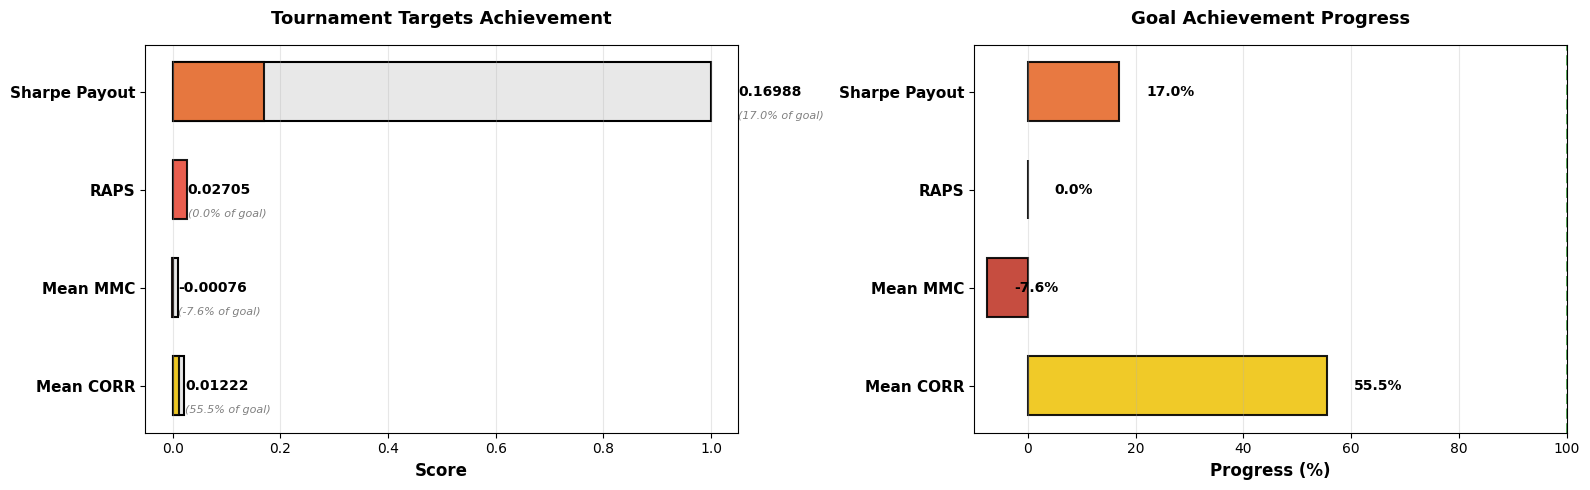

Category,Metric,Value,Goal,Status,Note
Payout,RAPS,+0.0271,+0,✅ MET,Risk-adjusted payout proxy with drawdown and tail-risk penalties
Payout,Mean MMC (BMC Proxy),-0.00076,+0.01,🔴 BELOW,Uniqueness vs benchmark (2× NMR multiplier)
Payout,Mean CORR,+0.01222,+0.022,🟠 LAGGING,Official Numerai correlation score (0.5× multiplier)
Risk,Sharpe Ratio,+0.8894,+1,🟡 CLOSE,Risk-adjusted return consistency
Risk,Payout Sharpe,+0.1699,+1,🔴 BELOW,Sharpe ratio of payout proxy (0.5×CORR + 2×MMC)
Risk,MMC Volatility,0.01060,—,—,Standard deviation of era-by-era MMC
Risk,Max Drawdown,-0.12436,-0.05,🟡 CLOSE,Worst sustained CORR cumulative loss
Quality,Mean FNC,+0.00797,+0,✅ MET,CORR after removing linear feature exposure
Quality,Win Rate,80.6%,+0.55,✅ MET,Fraction of eras with positive CORR
Uniqueness,P95 Max Feature Exposure,0.3262,+0.2,🔴 EXCEEDED,95th percentile of strongest single-feature correlation


,CORR,MMC,FNC,MAX_FEATURE_EXPOSURE,BENCHMARK_PRED_CORR,PAYOUT_PROXY,CUM_CORR,DRAWDOWN_CORR
era,,,,,,,,
1199,0.006058,0.012185,0.016962,0.318911,0.359466,0.027399,7.641108,0.091492
1200,-0.007330,-0.000495,-0.010343,0.320371,0.362124,-0.004655,7.633778,0.098822
1201,-0.001117,-0.001714,0.014468,0.314687,0.370447,-0.003986,7.632661,0.099938
1202,0.000365,-0.003592,0.006757,0.301831,0.374508,-0.007000,7.633026,0.099573
1203,0.001502,0.005127,-0.000724,0.318908,0.379933,0.011005,7.634528,0.098072


In [14]:
# Calculate metrics and compare this run against prior recorded models
print("\nEnsemble validation performance:")

validation_for_metrics, benchmarks_for_metrics, benchmark_col = prepare_metric_inputs(
    validation,
    val_benchmarks,
 )

metrics, per_era_df = calculate_metrics(
    df_validation=validation_for_metrics,
    benchmarks=benchmarks_for_metrics[[benchmark_col]],
    features=features,
    target_col="target",
    benchmark_col=benchmark_col,
 )

display_metrics_table(metrics, extended=True)
display(per_era_df.tail())

history_df, current_run = record_model_metrics(
    metrics=metrics,
    model_name=cfg.MODEL_NAME,
    notebook_name=NOTEBOOK_PATH.stem,
 )

leaderboard_df, is_top = compare_top_models_with_current(
    current_run_id=current_run["run_id"],
    top_n=4,
    show_message=True,
 )

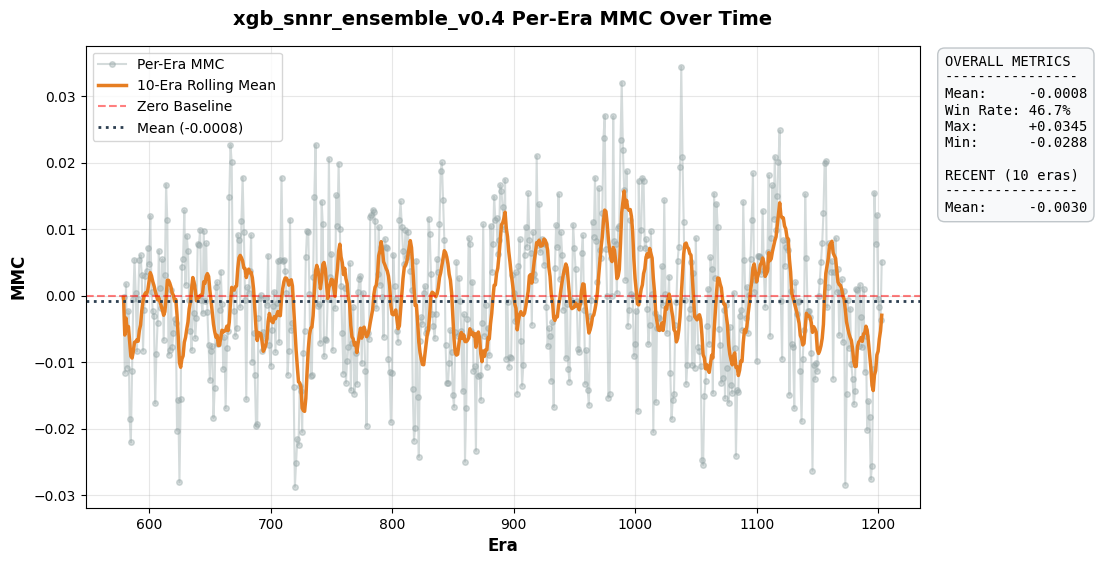

In [15]:
# Plot performance metrics
from utils.visualization import plot_metric_over_time


plot_metric_over_time(per_era_df, metric="MMC", title=f"{cfg.MODEL_NAME} Per-Era MMC Over Time")

---------
------

In [ ]:
assert False

In [16]:
# =============================================================================
# 5. Production Export
# =============================================================================
import cloudpickle

def predict(live_features: pd.DataFrame):
    # Ensure 'id' is index for consistency
    if "id" in live_features.columns: live_features.set_index("id", inplace=True)
    
    preds = predict_ensemble(live_features, trained_models, features, cfg)
    return pd.DataFrame({"prediction": preds}, index=live_features.index)

with open("finance_arena_v0_4_improved.pkl", "wb") as f:
    cloudpickle.dump(predict, f)